# `criticality.ipynb`: compute dynamical exponent
## Initialize

In [1]:
from jax import numpy as jnp
import matplotlib
from matplotlib import pyplot as plt
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
from pathlib import Path
from scipy.stats import linregress, norm

from utils.bootstrap_argmax import *
from utils.modelIO import *
from utils.phases import *

In [2]:
GIDS_PATH = Path('data/eml/eml_gene_ids.csv')
BIO_GRN_PATH = Path('data/eml/eml_fate_network.npy')
BIO_SIM_PATH = Path('results/eml/bio_T_fine/')
FIG_SAVE_PATH = Path('figs/eml/')

_, _, N = load_grn(BIO_GRN_PATH, GIDS_PATH)
temperatures = jnp.linspace(1.0, 2.5, 151)

## Load data and compute/plot correlation times

In [3]:
bio_fns = [BIO_SIM_PATH.joinpath('bio_mT_{:03}_xs.npy'.format((100*T).astype(int))) for T in temperatures]
bio_t_corr = jnp.array([get_ac_time(jnp.load(bio_fn)[:, N:], N) for bio_fn in bio_fns])


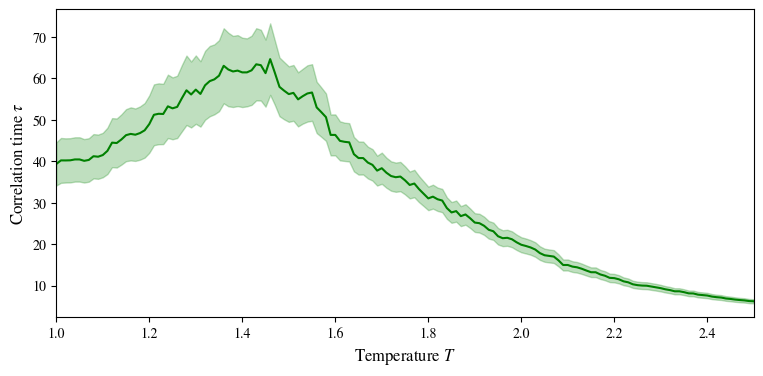

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(temperatures, bio_t_corr.T[0], c='g', label='EMP fate network')
ax.fill_between(temperatures, bio_t_corr.T[0]-1.96*bio_t_corr.T[1], bio_t_corr.T[0]+1.96*bio_t_corr.T[1],
                color='g', alpha=0.25)
ax.set_xlim(1.0, 2.5)
ax.set_xlabel(r'Temperature $T$', fontsize=12)
ax.set_ylabel(r'Correlation time $\tau$', fontsize=12)
plt.savefig(FIG_SAVE_PATH.joinpath('correlation_times.pdf'), bbox_inches='tight')

## Compute critical temperatures
Get temperatures in 95% CI

In [5]:
mean, ba_ci_lo, ba_ci_hi = bootstrap_argmax(bio_t_corr.T[0], ci=jnp.sqrt(0.95)*100)
ci_temperatures = temperatures[ba_ci_lo:ba_ci_hi]
Tg = temperatures[mean]
print('EMP fate network critical temperature: {:.2f}, 95% CI: [{:.2f}, {:.2f}]'.format(Tg, float(temperatures[ba_ci_lo]), float(temperatures[ba_ci_hi])))

EMP fate network critical temperature: 1.46, 95% CI: [1.31, 1.59]


## Compute critical exponents

In [6]:
crit_exps = jnp.zeros((ci_temperatures.shape[0], 3))

for i in range(len(ci_temperatures)):
    T = ci_temperatures[i]
    xs_path = BIO_SIM_PATH.joinpath('bio_mT_{:03}_xs.npy'.format((100*T).astype(int)))
    C = get_avg_autocorrelation(jnp.load(xs_path), N)
    t = jnp.arange(C.shape[0])
    mask = (C > 0) & (t > 0)
    neg_crit_exp, _, r, _, se = linregress(jnp.log(t)[mask], jnp.log(C)[mask])
    crit_exps = crit_exps.at[i].set([-neg_crit_exp, se, r**2])

ci_z = norm.ppf(0.5+jnp.sqrt(0.95)/2)
ce_ci_lo = jnp.min(crit_exps[:, 0]-ci_z*crit_exps[:, 1])
ce_ci_hi = jnp.max(crit_exps[:, 0]+ci_z*crit_exps[:, 1])
print('95% CI: {}'.format(np.array((ce_ci_lo, ce_ci_hi))))

95% CI: [0.36961958 0.7741154 ]


In [7]:
crit_exp_mean = crit_exps[mean-ba_ci_lo]
r2_mean = float(crit_exp_mean[2])
crit_exp_mean_val = float(crit_exp_mean[0])
print('EMP fate network: x = {:.2f}, r^2 = {:.2f}'.format(crit_exp_mean_val, r2_mean))

EMP fate network: x = 0.55, r^2 = 0.93
